# Backtest Workflow Template

这个 notebook 按 `run_backtest.py` 的主流程拆成几个阶段，方便在研究环境里逐段检查：

1. 参数与配置
2. 加载组件与策略
3. 加载股票池与行情
4. 生成信号并检查
5. 执行回测
6. 分析结果
7. 可选导出

相比直接调用 CLI，这里额外补了几个研究时很有用的检查点：被跳过股票统计、样本信号预览、回测摘要、净值和回撤图。

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm


def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "run_backtest.py").exists() and (candidate / "config" / "settings.yaml").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root from the current working directory.")


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = J:\workspace\2_quant\quant_system


## 1. 参数与配置

这里集中设置 notebook 本次运行的参数，尽量保持和 `run_backtest.py` 的参数语义一致。

In [2]:
config_path = PROJECT_ROOT / "config" / "settings.yaml"
strategy_config_path = PROJECT_ROOT / "config" / "strategies.yaml"

strategy_names = ["ma_cross"]
start_date = "2023-01-01"
end_date = "2023-12-31"

stock_file = None
stock_max_number = 5
initial_capital = None
trade_amount = None
adjust_mode = None

enable_stop_loss = True
enable_stop_profit = True

signal_combination = "weighted"  # weighted | voting | unanimous
signal_weights = None
signal_threshold = 0.5

sample_symbol = None
show_progress = True
export_results = False

## 2. 加载组件与策略

这一段对应 `run_backtest.py` 里读 YAML、实例化策略、读取止盈止损配置、合成运行参数的部分。

In [3]:
from backtest.engine import BacktestEngine
from backtest.metrics import calculate_max_drawdown, calculate_sharpe_ratio
from backtest.performance import PerformanceAnalyzer
from data.data_api import DataAPI
from run_backtest import create_strategy_function
from signals.signal_engine import SignalEngine
from signals.strategy_loader import StrategyLoader


with open(config_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

strategy_loader = StrategyLoader(str(strategy_config_path))
strategies, strategy_infos = strategy_loader.build_timing_strategies(strategy_names)
signal_engine = SignalEngine()

if signal_weights is None:
    signal_weights = [1.0 / len(strategies)] * len(strategies)
elif len(signal_weights) != len(strategies):
    raise ValueError(
        f"Signal weight count ({len(signal_weights)}) does not match strategy count ({len(strategies)})."
    )

min_data_length = max(info.get("min_data_length", 20) for info in strategy_infos)
backtest_config = strategy_loader.config.get("backtest", {})

runtime = {
    "start_date": start_date or config["backtest"].get("start_date", "2022-01-01"),
    "end_date": end_date or config["backtest"].get("end_date", "2023-12-31"),
    "initial_capital": initial_capital or backtest_config.get(
        "initial_capital", config["backtest"]["initial_capital"]
    ),
    "trade_amount": trade_amount or config["backtest"].get("trade_amount", 100000),
    "stock_file": stock_file or config["data"].get("stock_file", "./data/test1.txt"),
    "adjust_mode": adjust_mode or config["data"].get("adjust_mode", "hfq"),
    "data_source": config["data"].get("source", "akshare"),
}

(
    stop_loss_strategy,
    stop_loss_info,
    stop_profit_strategy,
    stop_profit_info,
) = strategy_loader.build_stop_strategies(
    enable_stop_loss=enable_stop_loss,
    enable_stop_profit=enable_stop_profit,
)

display(pd.DataFrame({
    "value": {
        "strategy_names": ", ".join(strategy_names),
        "start_date": runtime["start_date"],
        "end_date": runtime["end_date"],
        "stock_file": runtime["stock_file"],
        "stock_max_number": stock_max_number,
        "adjust_mode": runtime["adjust_mode"],
        "initial_capital": runtime["initial_capital"],
        "trade_amount": runtime["trade_amount"],
        "signal_combination": signal_combination,
        "signal_weights": signal_weights,
        "signal_threshold": signal_threshold,
        "min_data_length": min_data_length,
        "stop_loss": stop_loss_info["params"] if stop_loss_info else "disabled",
        "stop_profit": stop_profit_info["params"] if stop_profit_info else "disabled",
    }
}))

if signal_combination == "unanimous" and sum(signal_weights) <= 1.000001:
    print(
        "Warning: run_backtest.py currently derives unanimous mode from the weighted score. "
        "With normalized weights, unanimous signals may never trigger."
    )

,value
strategy_names,ma_cross
start_date,2023-01-01
end_date,2023-12-31
stock_file,./data/HS300.txt
stock_max_number,5
adjust_mode,qfq
initial_capital,500000
trade_amount,10000
signal_combination,weighted
signal_weights,[1.0]


## 3. 准备辅助函数

把 `run_backtest.py` 里几段行内逻辑整理成 notebook 内部函数，方便逐步调试。

In [4]:
PRICE_COLUMNS = [
    "date",
    "code",
    "open",
    "close",
    "high",
    "low",
    "volume",
    "amount",
    "amplitude",
    "pct_change",
    "change",
    "turnover",
]


def prepare_price_frame(df: pd.DataFrame) -> pd.DataFrame:
    prepared = df.copy()
    prepared.columns = PRICE_COLUMNS
    prepared["date"] = pd.to_datetime(prepared["date"])
    prepared = prepared.set_index("date").sort_index()
    return prepared


def combine_strategy_signals(signals_list: list[pd.Series]) -> pd.Series:
    combined_signal = signal_engine.combine_signals(signals_list, signal_weights)
    if signal_combination == "weighted":
        return combined_signal.apply(
            lambda x: 1 if x >= signal_threshold else (-1 if x <= -signal_threshold else 0)
        )
    if signal_combination == "voting":
        vote_signal = pd.Series(0, index=signals_list[0].index)
        for signal in signals_list:
            vote_signal += signal
        return vote_signal.apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))
    if signal_combination == "unanimous":
        return combined_signal.apply(
            lambda x: 1 if x >= (len(strategies) - 0.5) else (-1 if x <= -(len(strategies) - 0.5) else 0)
        )
    return combined_signal.apply(
        lambda x: 1 if x >= signal_threshold else (-1 if x <= -signal_threshold else 0)
    )


def create_strategy_function_compatible(trade_amount_value: float):
    def is_missing(value) -> bool:
        try:
            return bool(pd.isna(value))
        except AttributeError:
            return value != value

    def strategy_func(date, data, positions):
        signals = {}
        for symbol, df in data.items():
            if date not in df.index:
                continue

            current_signal = df.loc[date, "signal"]
            if is_missing(current_signal):
                continue

            current_pos = positions.get(symbol, 0)
            current_price = df.loc[date, "close"]
            if is_missing(current_price) or current_price <= 0:
                continue

            shares = int(trade_amount_value / current_price)
            if current_signal == 1 and current_pos == 0:
                signals[symbol] = {"action": "buy", "shares": shares}
            elif current_signal == -1 and current_pos > 0:
                signals[symbol] = {"action": "sell", "shares": current_pos}

        return signals

    return strategy_func


def summarize_signal(series: pd.Series) -> pd.DataFrame:
    return series.value_counts(dropna=False).rename_axis("signal").to_frame("count")

## 4. 加载股票池与行情

这一段对应 `run_backtest.py` 中的 `DataAPI` 初始化、股票池读取、历史行情加载、列名标准化和价格有效性过滤。

In [5]:
data_api = DataAPI(
    source=runtime["data_source"],
    stock_file=runtime["stock_file"],
    cache_dir=config["data"]["cache_dir"],
    processed_dir=config["data"]["processed_dir"],
    adjust_mode=runtime["adjust_mode"],
)

stock_list = data_api.get_stock_list()
if stock_max_number != -1 and len(stock_list) > stock_max_number:
    stock_list = stock_list[:stock_max_number]

data = {}
load_records = []

for symbol in tqdm(stock_list, desc="Loading data", unit="symbol", disable=not show_progress):
    raw_df = data_api.get_price_history_data(symbol, runtime["start_date"], runtime["end_date"])
    if raw_df is None or raw_df.empty:
        load_records.append({"symbol": symbol, "rows": 0, "status": "empty", "detail": "no rows returned"})
        continue

    df = prepare_price_frame(raw_df)
    invalid_prices = data_api.detect_non_positive_prices(df)
    if invalid_prices:
        detail = ", ".join(f"{column}={count}" for column, count in invalid_prices.items())
        load_records.append({"symbol": symbol, "rows": len(df), "status": "skipped", "detail": detail})
        continue

    if len(df) < min_data_length:
        df["signal"] = np.nan
        status = "too_short"
        detail = f"len={len(df)} < min_data_length={min_data_length}"
    else:
        status = "ready"
        detail = "ok"

    data[symbol] = df
    load_records.append({"symbol": symbol, "rows": len(df), "status": status, "detail": detail})

load_summary = pd.DataFrame(load_records)
display(load_summary)
print(f"Loaded valid symbols: {len(data)} / {len(stock_list)}")

if not data:
    raise ValueError(
        f"No valid price data loaded for backtest. Please check stock universe and adjust_mode={data_api.adjust_mode_label}."
    )

ready_symbols = [symbol for symbol, df in data.items() if len(df) >= min_data_length]

if sample_symbol is None:
    sample_symbol = ready_symbols[0] if ready_symbols else next(iter(data.keys()))

print(f"Sample symbol for signal inspection: {sample_symbol}")

Loading data:   0%|          | 0/5 [00:00<?, ?symbol/s]

,symbol,rows,status,detail
0,688981,242,ready,ok
1,688599,242,ready,ok
2,688561,242,ready,ok
3,688396,242,ready,ok
4,688363,242,ready,ok


Loaded valid symbols: 5 / 5
Sample symbol for signal inspection: 688981


## 5. 生成信号并检查

这一段和 `run_backtest.py` 的信号生成逻辑保持一致，但额外保留样本股票的中间信号，方便确认策略是否按预期工作。

In [6]:
signal_debug = {}

for symbol, df in tqdm(data.items(), desc="Generating signals", unit="symbol", disable=not show_progress):
    if len(df) < min_data_length:
        continue

    if len(strategies) == 1:
        signal_series = strategies[0].generate_signal(df)
        signal_debug_map = {strategy_names[0]: signal_series}
    else:
        signals_list = [strategy.generate_signal(df) for strategy in strategies]
        signal_series = combine_strategy_signals(signals_list)
        signal_debug_map = {
            name: signal
            for name, signal in zip(strategy_names, signals_list)
        }
        signal_debug_map["combined_score"] = signal_engine.combine_signals(signals_list, signal_weights)

    df["signal"] = signal_series
    if symbol == sample_symbol:
        signal_debug = signal_debug_map

display(summarize_signal(data[sample_symbol]["signal"]))

sample_debug = pd.DataFrame(index=data[sample_symbol].index)
sample_debug["close"] = data[sample_symbol]["close"]
for name, signal in signal_debug.items():
    sample_debug[name] = signal

display(sample_debug.tail(20))

Generating signals:   0%|          | 0/5 [00:00<?, ?symbol/s]

,count
signal,
0,94
1,83
-1,65


,close,ma_cross
date,,
2023-12-04,53.18,-1
2023-12-05,52.39,-1
2023-12-06,51.97,-1
2023-12-07,52.67,-1
2023-12-08,52.55,-1
2023-12-11,53.18,-1
2023-12-12,54.12,-1
2023-12-13,53.75,-1
2023-12-14,53.10,-1


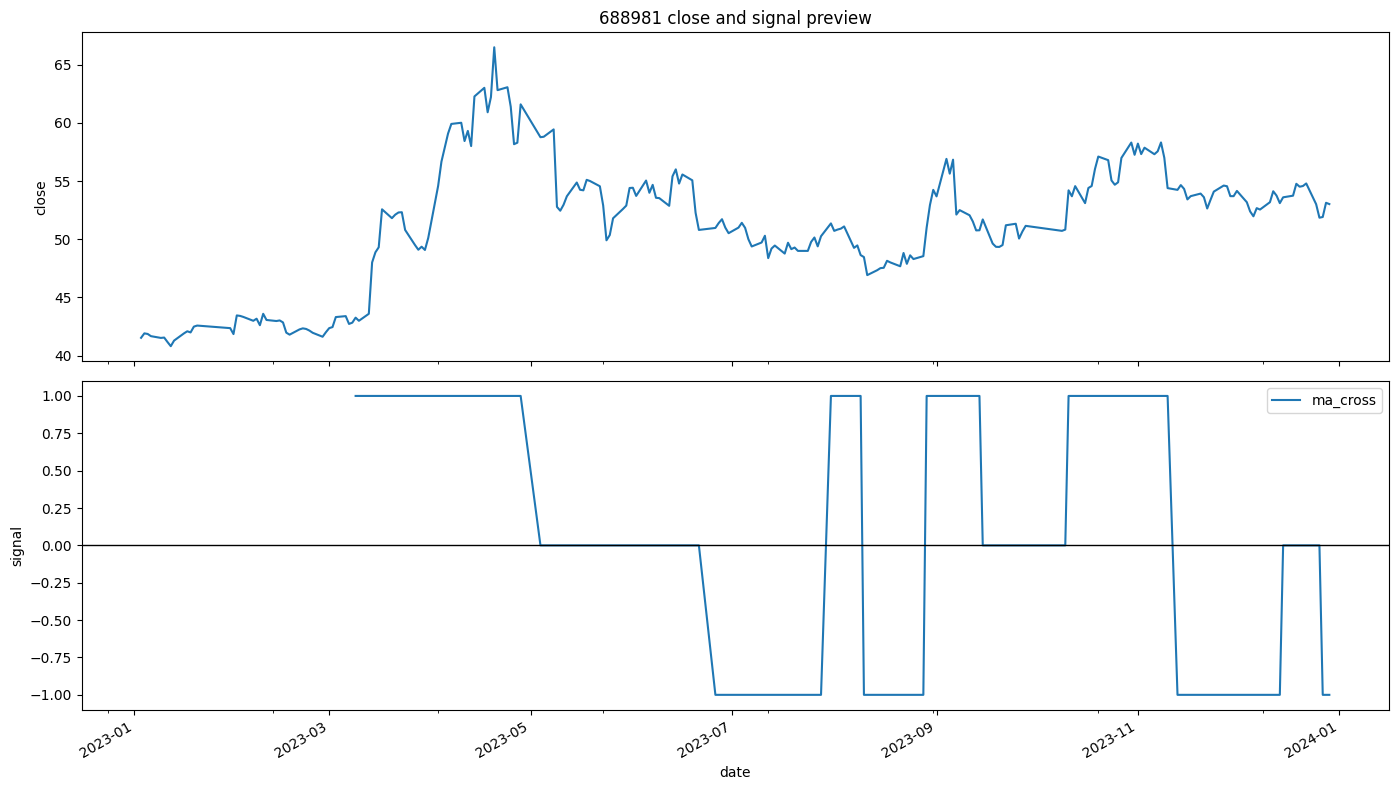

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

sample_debug["close"].plot(ax=axes[0], title=f"{sample_symbol} close and signal preview")
axes[0].set_ylabel("close")

signal_columns = [column for column in sample_debug.columns if column != "close"]
if signal_columns:
    sample_debug[signal_columns].tail(200).plot(ax=axes[1])
    axes[1].set_ylabel("signal")
    axes[1].axhline(0, color="black", linewidth=1)
else:
    axes[1].text(0.5, 0.5, "No signal columns available for preview", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

## 6. 执行回测

这一段对齐 `BacktestEngine` 的实际运行流程，并生成 `results` 与 `trades`。

In [8]:
engine = BacktestEngine(
    initial_capital=runtime["initial_capital"],
    commission_rate=config["backtest"]["commission_rate"],
    slippage=config["backtest"]["slippage"],
    config_path=str(config_path),
)

engine.set_stop_strategies(
    stop_loss_strategy=stop_loss_strategy,
    stop_profit_strategy=stop_profit_strategy,
)

strategy_func = create_strategy_function_compatible(runtime["trade_amount"])
results = engine.run(
    data,
    strategy_func,
    runtime["start_date"],
    runtime["end_date"],
    show_progress=show_progress,
)
trades = engine.get_trades()

results["returns"] = results["portfolio_value"].pct_change()
results["cumulative_returns"] = (1 + results["returns"].fillna(0)).cumprod()
results["drawdown"] = results["portfolio_value"] / results["portfolio_value"].cummax() - 1

completed_trades = trades[trades["action"] == "sell"] if not trades.empty else trades
win_rate = (
    (completed_trades["profit"] > 0).mean()
    if not completed_trades.empty and "profit" in completed_trades.columns
    else 0.0
)

summary = pd.DataFrame(
    {
        "value": {
            "loaded_symbols": len(data),
            "result_rows": len(results),
            "trade_rows": len(trades),
            "final_portfolio_value": results["portfolio_value"].iloc[-1],
            "total_return_pct": (results["portfolio_value"].iloc[-1] / runtime["initial_capital"] - 1) * 100,
            "sharpe_ratio": calculate_sharpe_ratio(results["returns"].dropna()),
            "max_drawdown_pct": calculate_max_drawdown(results["portfolio_value"]) * 100,
            "max_positions": results["positions"].apply(len).max(),
            "win_rate_pct": win_rate * 100,
        }
    }
)

display(summary)
display(results.tail())
display(trades.tail())

回测进度: 100%|█████████████████████████████████████████████████████████████| 242/242 [00:00<00:00, 562.40天/s, 市值=498,495, 持仓=0]天/s]

{'prices': 0.04745793342590332, 'signals': 0.05493450164794922, 'stop_check': 0.016978025436401367, 'trades': 0.00099945068359375, 'portfolio': 0.0, 'daily_values': 0.0}


,value
loaded_symbols,5.000000
result_rows,242.000000
trade_rows,40.000000
final_portfolio_value,498494.680660
total_return_pct,-0.301064
sharpe_ratio,-3.833401
max_drawdown_pct,-1.265401
max_positions,3.000000
win_rate_pct,35.000000


,portfolio_value,cash,positions,returns,cumulative_returns,drawdown
date,,,,,,
2023-12-25,498494.68066,498494.68066,{},0.0,0.996989,-0.012192
2023-12-26,498494.68066,498494.68066,{},0.0,0.996989,-0.012192
2023-12-27,498494.68066,498494.68066,{},0.0,0.996989,-0.012192
2023-12-28,498494.68066,498494.68066,{},0.0,0.996989,-0.012192
2023-12-29,498494.68066,498494.68066,{},0.0,0.996989,-0.012192


,date,symbol,action,shares,price,cost,avg_cost,reason,revenue,profit,profit_pct
35,2023-09-12,688396,sell,177,55.09,9949.608252,NaN,strategy,9747.029628,-202.578624,-2.036046
36,2023-09-18,688981,sell,190,49.63,9978.990000,NaN,stop_loss,9425.928120,-553.061880,-5.542263
37,2023-09-25,688561,sell,186,50.85,9986.613048,NaN,stop_loss,9454.316760,-532.296288,-5.330098
38,2023-10-11,688981,buy,184,54.20,9976.789120,54.22168,strategy,NaN,NaN,NaN
39,2023-11-10,688981,sell,184,54.39,9976.789120,NaN,stop_profit,10003.756896,26.967776,0.270305


## 7. 结果分析

除了 CLI 日志摘要，这里再补一层 notebook 里更直观的图表和报告。

,metric,value
0,total_return,-0.003011
1,annual_return,-0.003135
2,annual_volatility,0.008639
3,sharpe_ratio,-3.835627
4,max_drawdown,-0.012654
5,calmar_ratio,-0.247736
6,win_rate,0.265560
7,avg_win,0.000466
8,avg_loss,-0.000490
9,profit_loss_ratio,0.951781


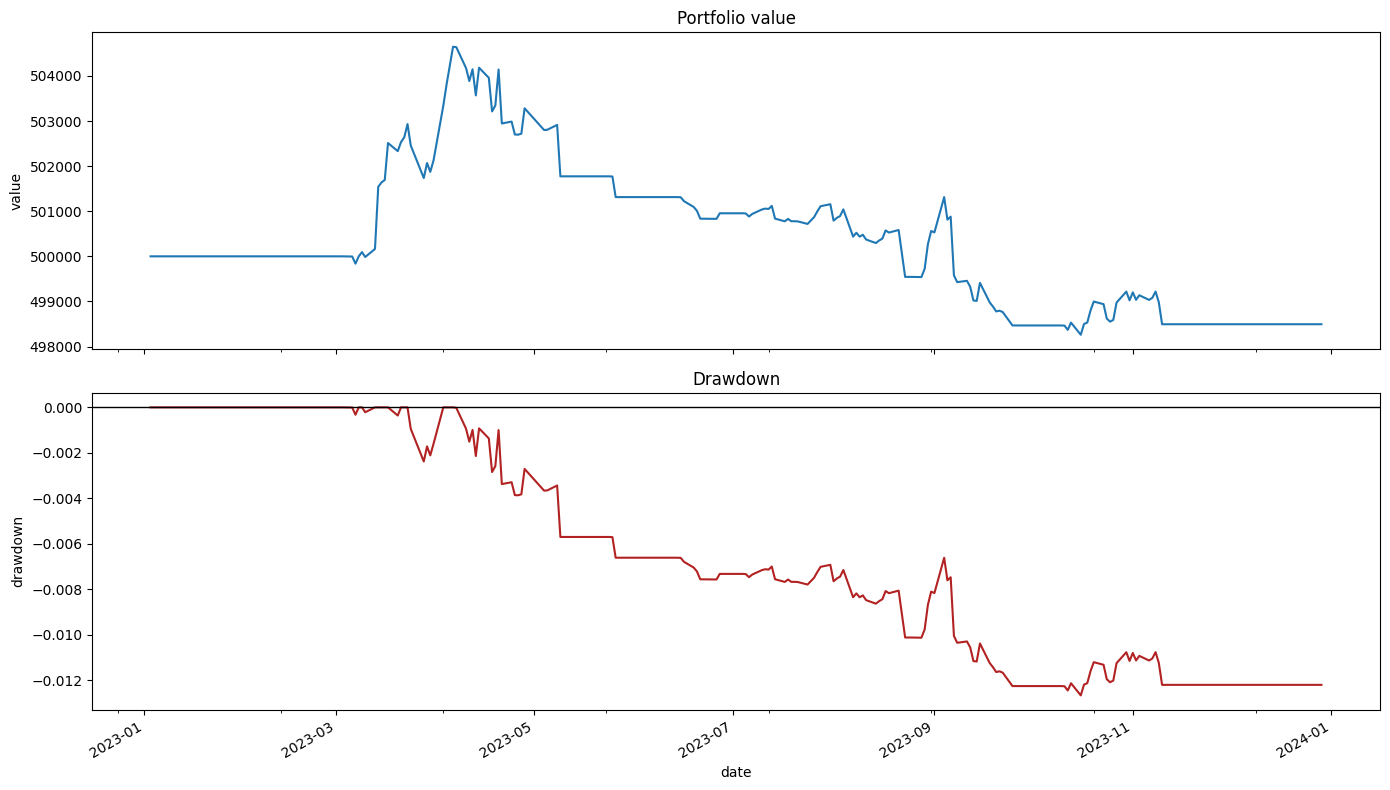

In [9]:
analyzer = PerformanceAnalyzer()
analysis = analyzer.analyze(results["portfolio_value"])

analysis_report = pd.DataFrame(
    {
        "metric": [
            "total_return",
            "annual_return",
            "annual_volatility",
            "sharpe_ratio",
            "max_drawdown",
            "calmar_ratio",
            "win_rate",
            "avg_win",
            "avg_loss",
            "profit_loss_ratio",
        ],
        "value": [
            analysis["total_return"],
            analysis["annual_return"],
            analysis["annual_volatility"],
            analysis["sharpe_ratio"],
            analysis["max_drawdown"],
            analysis["calmar_ratio"],
            analysis["win_rate"],
            analysis["avg_win"],
            analysis["avg_loss"],
            analysis["profit_loss_ratio"],
        ],
    }
)

display(analysis_report)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
results["portfolio_value"].plot(ax=axes[0], title="Portfolio value")
axes[0].set_ylabel("value")

results["drawdown"].plot(ax=axes[1], title="Drawdown", color="firebrick")
axes[1].set_ylabel("drawdown")
axes[1].axhline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

## 8. 可选导出

研究阶段通常需要同时留存净值序列和成交记录，所以这里把两份 CSV 都做成可选导出。

In [ ]:
if export_results:
    output_dir = PROJECT_ROOT / "output"
    output_dir.mkdir(parents=True, exist_ok=True)
    timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
    strategy_name_str = "_".join(strategy_names)
    results_path = output_dir / f"backtest_{strategy_name_str}_{timestamp}.csv"
    trades_path = output_dir / f"trades_{strategy_name_str}_{timestamp}.csv"

    results.to_csv(results_path)
    trades.to_csv(trades_path, index=False)

    print(f"Saved results to: {results_path}")
    print(f"Saved trades to: {trades_path}")
else:
    print("Set export_results = True to save backtest and trade CSV files.")

## 9. 流程检查结论

当前 `run_backtest.py` 的主流程整体是合理的：参数加载、策略实例化、数据标准化、信号生成、引擎回测、结果统计这条主链是完整的。

在研究型 notebook 里，建议额外保留这些环节：

- 数据质量检查：确认哪些股票因为非正价格或样本长度不足被跳过。
- 信号中间态检查：至少对一只样本股票保留单策略信号和合成后信号。
- 结果图表：净值和回撤通常比日志更适合研究阶段快速判断。
- 同步导出 `backtest_*.csv` 和 `trades_*.csv`：方便后续给 `app_backtest.py` 直接消费。
- 多策略模式下的组合逻辑检查：特别是 `unanimous` 模式，当前实现和归一化权重组合在一起时需要格外留意。